# **EDKP 616: Individual Reading** #
---
## **Section 1 : Sources of Measurement Error in Marker-based Motion Capture** ##
---

#### Why measurement error matters: ####

A joint angle is at the end of a long chain (calibration, 3D reconstruction, gap filling, filtering, a marker-to-bone assumption, angle calculation), and an error at any step reaches the final angle. For skin markers, the literature identifies three main error types: **instrumental errors**, **soft tissue artefact (STA)** and **anatomical landmark misplacement** ([Cappozzo et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.01.010); [Chiari et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.04.004); [Leardini et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.05.002)). Added to that are two more practical ones : **marker visibility problems** and **processing choices** (gap filling, filtering) ([Della Croce et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.05.003)).

When markers are closer together, there is a bigger angle error for the same error in millimeters. That applies especially for foot models such as the Oxford Foot Model (OFM), whose markers can be a few centimetres apart ([Carson et al., 2001](https://doi.org/10.1016/S0021-9290(01)00101-4)).

#### Setting up: data and a simple angle ####

I use the sample walking trial from openOFM ([Dixon et al., 2025](https://doi.org/10.1080/10255842.2024.2448558)): 2.05 s at 100 Hz, in the `data` folder. Since it is **already processed**, it cannot show raw errors. Instead I **add known errors** to the real markers and measure how much an angle changes; the original data is the "truth".

The angle is a **foot angle**: the angle of the line from the heel marker (RHEE) to the toe marker (RTOE), seen from the side and measured in degrees (0° is a flat foot, positive means toes up):

$$\theta = \arctan\left(\frac{\text{height difference}}{\text{forward distance}}\right)$$

This is not a full joint angle, but it shows how marker errors become angle errors. The notebook calls short functions from `utils/error_functions.py`. The heel-to-toe distance is 206 mm.

**How to read this notebook.** Each section explains one error source, adds that error to the real data **(truth)** with code, and comments on the result. Since I know the size of every error I add, I can measure exactly how much it changes the foot angle. In a real study the true error is unknown, which is why a simulation like this is useful.

In [1]:
import numpy as np                          # used for random numbers only
import utils.error_functions as ef          # all our functions
toe_y, toe_z, heel_y, heel_z, time = ef.load_foot('data/dynamic.c3d')
n = len(time)                               # number of frames

In [2]:
true_angle = ef.foot_angle(toe_y, toe_z, heel_y, heel_z)    # the 'truth'

All the calculations are in `utils/error_functions.py` and the notebook only calls them. The first cell imports them and loads the data with `load_foot()`. The second cell calculates the true angle with `foot_angle()` (the formula above).

#### 1. Instrumental errors: ####

Cameras find a marker's 3D position by triangulation. Calibration errors, lens distortion and pixel size cause **systematic errors** (bias) and **random errors** (noise) ([Chiari et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.04.004)). *Accuracy* is closeness to the true value; *precision* is repeatability, checked with a static trial (a still marker should not move).

If two markers are $L$ apart and each coordinate has noise with standard deviation $\sigma$, the direction of the line between them has an error of about

$$\sigma_\theta \approx \frac{\sqrt{2}\,\sigma}{L}\ \ \text{(radians)}$$

The code adds 1 mm of random noise to each coordinate and plots the foot angle with and without noise, then prints the formula for different distances.

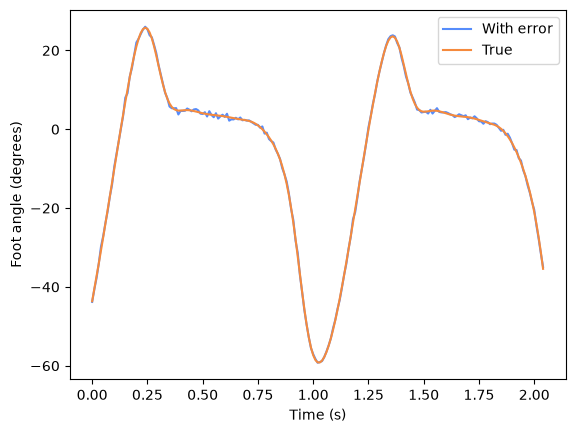

Largest error: 1.1 degrees
25 mm apart: about 3.2 degrees
50 mm apart: about 1.6 degrees
100 mm apart: about 0.8 degrees
200 mm apart: about 0.4 degrees


In [3]:
np.random.seed(42)                          # same 'random' numbers each time
toe_y_noisy = ef.add_noise(toe_y, 1)        # add 1 mm of random noise
toe_z_noisy = ef.add_noise(toe_z, 1)
heel_y_noisy = ef.add_noise(heel_y, 1)
heel_z_noisy = ef.add_noise(heel_z, 1)
new_angle = ef.foot_angle(toe_y_noisy, toe_z_noisy, heel_y_noisy, heel_z_noisy)
ef.plot_angles(time, true_angle, new_angle)
error = ef.largest_error(new_angle, true_angle)
print('Largest error: {:.1f} degrees'.format(error))

for distance in [25, 50, 100, 200]:         # distance between markers (mm)
    error = ef.angle_noise(distance, 1)     # for 1 mm of noise
    print('{} mm apart: about {:.1f} degrees'.format(distance, error))

With 1 mm of noise, the foot angle is wrong by up to **1.1°** ; the typical error is about 0.4°, as the formula predicts for 206 mm. The same noise gives 0.4° for markers 200 mm apart but **3.2° for markers 25 mm apart**, as on the OFM forefoot and hallux.

A good example would be a weighing scale. Let's say that scale A always reads 2 kg too high, but gives the same number every time. This is **bias**. It is consistent but wrong. On the other hand, Scale B shows a different number each time you step on it, sometimes higher and sometimes lower, but its average is right. **This is noise**. **Noise is like camera jitter,** where a still marker seems to shake a bit between frames. **Bias is like a calibration error** or a marker placed in the wrong spot, where it is always off by the same amount. In conclusion, filtering and averaging fix noise but not bias, so you need different fixes for each.

#### 2. Marker visibility: ####

A marker is reconstructed only if enough cameras see it. Occlusions create **gaps**; reflections create **ghost markers** (points that do not exist); and crossing markers can have their **labels swapped**. From a more practical perspective, if you make the participants walk on a irregular surface, you could get occlusions and if the blinds are open, the sun could reflect on things that are not markers, creating ghost markers.In c3d files, a negative residual means a point was not reconstructed; the code lists markers that are not valid in every frame.

In [4]:
for name, valid in ef.short_markers('data/dynamic.c3d').items():
    print('{} is valid in only {} of {} frames'.format(name, valid, n))

*36 is valid in only 1 of 205 frames


All named markers are valid in every frame, therefore the sample was already cleaned and gap-filled. But` *36`, exists in **only 1 of 205 frames**, which is how a ghost marker often looks. It is harmless here, but a ghost marker that would have been given a label would cause a large one-frame error, so jumps in position should be checked. Gaps are **simulated** in section 5.1.

A ghost that lasts only one frame looks harmless, but every later step treats each frame as true. A filter would spread a sudden jump into the other frames, and differentiation would turn it into a large spike in velocity. This is why trajectories should be checked for sudden jumps **before** they are filtered.

#### 3. Soft tissue artefact (STA): ####

Markers are on the skin, but models assume they follow the bone. Unlike noise, STA is caused by the movement itself and has similar frequencies, so **filtering cannot remove it** ([Leardini et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.05.002)). A systematic review on the quantification of soft tissue artifact in lower limb human motion analysis found more than 30 mm at the thigh and about 15 mm at the shank ([Peters et al., 2010](https://doi.org/10.1016/j.gaitpost.2009.09.004)). It is limited by low-STA sites, marker clusters and model-based compensation ([Cereatti et al., 2006](https://doi.org/10.1186/1743-0003-3-7)).

I **simulate** a 2 Hz up-and-down skin movement (wobble) of 5 mm at the heel marker.

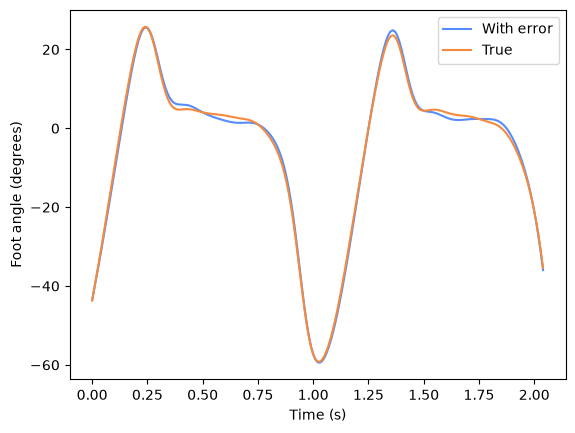

Largest error: 1.5 de2grees


In [5]:
wobble = ef.skin_movement(time, 5, 2)       # 5 mm, 2 times per second
new_angle = ef.foot_angle(toe_y, toe_z, heel_y, heel_z + wobble)   # on heel
ef.plot_angles(time, true_angle, new_angle)
error = ef.largest_error(new_angle, true_angle)
print('Largest error: {:.1f} de2grees'.format(error))

With no noise at all, the foot angle is wrong by up to **1.5°** (5 mm over 206 mm is about 1.4°), and the error looks like real movement, so it is hard to notice.

The 5 mm skin movement is a modest value chosen for demonstration; the literature reports much larger values at the thigh and shank ([Peters et al., 2010](https://doi.org/10.1016/j.gaitpost.2009.09.004)). The 1.5° result should therefore be read as an example of how a marker error becomes an angle error, not as a measured STA for the foot.

#### 4. Anatomical landmark misplacement: ####

Landmarks are found by touch through soft tissue, therefore their position varies between researchers. A misplaced marker stays wrong all session, giving a **constant offset** that filtering cannot remove. [Della Croce et al., 2005](https://doi.org/10.1016/j.gaitpost.2004.05.003) This study showed that small rotations in the secondary planes are the most affected and can be misread as real movement. OFM repeatability studies measure these errors by re-applying markers between sessions ([Carson et al., 2001](https://doi.org/10.1016/S0021-9290(01)00101-4); [Stebbins et al., 2006](https://doi.org/10.1016/j.gaitpost.2005.03.002)).

To simulate a researcher misplacing a marker, the code places the heel marker 5 mm too high and compares the foot angle with the truth.

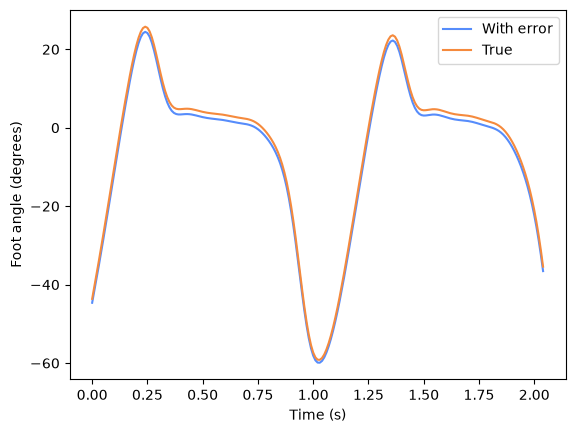

Largest error: 1.5 degrees
Average error: -1.3 degrees


In [6]:
new_angle = ef.foot_angle(toe_y, toe_z, heel_y, heel_z + 5)   # heel 5 mm high
ef.plot_angles(time, true_angle, new_angle)
error = ef.largest_error(new_angle, true_angle)
print('Largest error: {:.1f} degrees'.format(error))
average = (new_angle - true_angle).mean()   # average error, with its sign
print('Average error: {:.1f} degrees'.format(average))

The average error is **−1.3°** and the largest is 1.5°. The curve keeps its shape but is shifted, and neither averaging nor filtering can fix that. Just like scale B in the example above, that represents bias.

The difference with noise is important. Noise changes from frame to frame, so it partly averages out. A misplaced marker is wrong in the same way in every frame, so averaging keeps the error. If a different researcher places the marker the next day, the error changes, and a difference between two sessions may be mistaken for a real change in the person. This is why repeatability is a very important concept in a study.

#### 5. Data-processing errors: ####

##### 5.1 Gap filling: #####

**Linear interpolation** joins the points around the gap with a straight line and a **cubic spline** uses a smooth curve; both use only the marker's own data. A **rigid-body method** rebuilds the marker from the other markers of its segment, assuming the segment is rigid ([Cereatti et al., 2006](https://doi.org/10.1186/1743-0003-3-7)). In their study, [Howarth & Callaghan, 2010](https://doi.org/10.1080/10255841003664701) found that splines are better for short gaps and rigid-body methods are better for long ones, with a crossover near 200 ms. I only code the first two.

The code deletes 30, 100, 200 and 400 ms of the toe height in mid-swing, fills the gap both ways and compares with the original (toe height and foot angle). The plot shows the 400 ms gap.

30 ms gap, toe height error (mm): 1.2 linear, 0.0 spline
          foot angle error (deg): 0.2 linear, 0.0 spline
100 ms gap, toe height error (mm): 2.5 linear, 0.5 spline
          foot angle error (deg): 0.5 linear, 0.1 spline
200 ms gap, toe height error (mm): 29.1 linear, 8.3 spline
          foot angle error (deg): 8.4 linear, 2.3 spline
400 ms gap, toe height error (mm): 35.9 linear, 43.6 spline
          foot angle error (deg): 10.2 linear, 12.5 spline


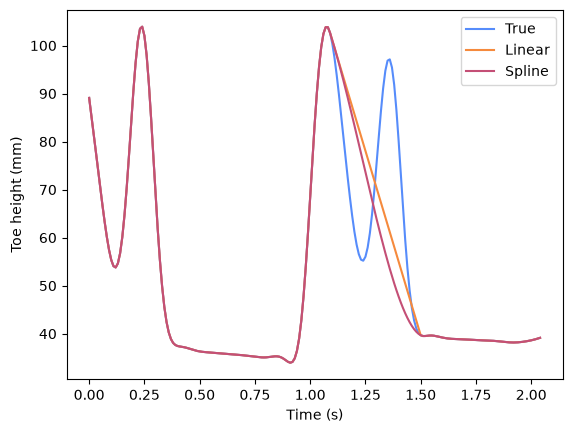

In [7]:
for gap in [3, 10, 20, 40]:                 # lost frames (30 to 400 ms)
    toe_z_gap = ef.delete_frames(toe_z, 110, gap)   # delete mid-swing
    linear = ef.fill_linear(toe_z_gap)      # fill with a straight line
    spline = ef.fill_spline(toe_z_gap)      # fill with a smooth curve
    linear_angle = ef.foot_angle(toe_y, linear, heel_y, heel_z)
    spline_angle = ef.foot_angle(toe_y, spline, heel_y, heel_z)
    linear_h = ef.largest_error(linear, toe_z)      # toe height errors
    spline_h = ef.largest_error(spline, toe_z)
    linear_a = ef.largest_error(linear_angle, true_angle)   # angle errors
    spline_a = ef.largest_error(spline_angle, true_angle)
    print('{} ms gap, toe height error (mm): {:.1f} linear, {:.1f} spline'
          .format(gap * 10, linear_h, spline_h))
    print('          foot angle error (deg): {:.1f} linear, {:.1f} spline'
          .format(linear_a, spline_a))
ef.plot_gap(time, toe_z, linear, spline)    # plot of the last gap (400 ms)

| Gap | 30 ms | 100 ms | 200 ms | 400 ms |
|:--:|:--:|:--:|:--:|:--:|
| **Linear, toe height (mm)** | 1.2 | 2.5 | 29.1 | 35.9 |
| **Spline, toe height (mm)** | 0.0 | 0.5 | 8.3 | 43.6 |
| **Linear, foot angle (°)** | 0.2 | 0.5 | 8.4 | 10.2 |
| **Spline, foot angle (°)** | 0.0 | 0.1 | 2.3 | 12.5 |

Up to 100 ms both methods are good (under 3 mm and 0.5°). At 200 ms the spline is much better (2.3° against 8.4°), but at 400 ms both fail and the spline is even a little worse, because a curve fitted around a long gap can overshoot. This is one gap in one trial, so the exact numbers depend on where the gap is. For gaps near 200 ms or longer the rigid-body method is probably better, because its error does not grow with gap length ([Howarth & Callaghan, 2010](https://doi.org/10.1080/10255841003664701)).

From these results I would suggest three habits: check the **length** of each gap before choosing a method; look at every filled gap of about 200 ms or more on a plot instead of trusting it; and **report** how many gaps were filled and with which method, so that readers can judge the data.

##### 5.2 Filtering: #####

Raw trajectories contain high-frequency noise, which grows when data are differentiated into velocity and acceleration. The usual fix is a low-pass **Butterworth filter** applied forwards and backwards. The cut-off is a **trade-off**: too high leaves noise, too low flattens real movement. [Winter, 2009](https://doi.org/10.1002/9780470549148) proposed residual analysis to choose it objectively.

I add 1 mm of noise to the real toe height and filter it with different cut-offs. The code also shows what differentiation does to the noise, and whether a 6 Hz filter keeps the skin movement from section 3.

In [8]:
np.random.seed(42)
noisy_toe_z = ef.add_noise(toe_z, 1)        # toe height with 1 mm of noise
error = ef.average_error(noisy_toe_z, toe_z)
print('No filter: average error {:.2f} mm'.format(error))
for cutoff in [4, 6, 10, 30]:               # cut-off frequency (Hz)
    filtered = ef.lowpass(noisy_toe_z, cutoff)
    error = ef.average_error(filtered, toe_z)
    print('{} Hz cut-off: average error {:.2f} mm'.format(cutoff, error))
error = ef.speed_error(noisy_toe_z, toe_z)  # error in the velocity
print('The 1 mm noise becomes {:.0f} mm/s in the velocity'.format(error))
kept = abs(ef.lowpass(wobble, 6)).max()     # a 6 Hz filter on the 2 Hz wobble
print('A 6 Hz filter keeps {:.1f} mm of the 5 mm skin wobble'.format(kept))

No filter: average error 0.74 mm
4 Hz cut-off: average error 3.15 mm
6 Hz cut-off: average error 0.94 mm
10 Hz cut-off: average error 0.31 mm
30 Hz cut-off: average error 0.56 mm
The 1 mm noise becomes 56 mm/s in the velocity
A 6 Hz filter keeps 5.0 mm of the 5 mm skin wobble


Without a filter the average error is 0.74 mm. A **10 Hz** cut-off gives the lowest error (0.31 mm). A higher cut-off (30 Hz) leaves more noise (0.56 mm), and lower ones remove real movement, so the error rises (0.94 mm at 6 Hz and 3.15 mm at 4 Hz, worse than no filter). Differentiating turns the 1 mm noise into an average velocity error of 56 mm/s. The 6 Hz filter keeps the whole 5 mm skin movement, because it is slower than the cut-off. **Filtering reduces noise, not soft tissue artefacr.**

The cut-off alone changed the error from 3.15 mm (4 Hz) to 0.31 mm (10 Hz), about ten times, from a processing choice only. Two studies on the same data could report different results with different cut-offs, so the cut-off should always be reported to let others repeat the analysis, once again putting emphasis on the importance of repeatability.

#### 6. Putting it together: a simple error budget ####

| **Error source (size used)** | **Largest foot-angle error** |
|:--:|:--:|
| Random noise (1 mm) | 1.1° |
| Soft tissue artefact (5 mm) | 1.5° |
| Landmark misplacement (5 mm) | 1.5° |
| 200 ms gap, linear fill | 8.4° |
| 200 ms gap, spline fill | 2.3° |

First, **gap handling can matter most**: a linear 200 ms fill gives 8.4°, five times the other errors, and a spline reduces it to 2.3°. Second, STA and landmark errors are as big as 1mm to 1.5mm of noise but **cannot be filtered away**, so good marker placement is the only defence. Third, these errors are small mainly because the heel-to-toe line is long (206 mm); 1 mm of noise gives 3.2° at 25 mm, so **small foot-model segments are far more sensitive**.

*Limitations:* one subject and trial, already processed; simple error models; a simple foot angle, not the OFM; the "truth" has its own unknown errors.

#### 7. Strategies to reduce measurement error: ####

| **Source** | **Strategies** |
|:--:|:--:|
| **Instrumental** | Calibrate each session; run spot-checks; report static precision |
| **Visibility** | Good camera placement; marker clusters; check for jumps |
| **STA** | Low-STA sites; rigid clusters; redundant markers |
| **Landmarks** | Standard palpation protocol; trained researchers; test repeatability ([Carson et al., 2001](https://doi.org/10.1016/S0021-9290(01)00101-4); [Stebbins et al., 2006](https://doi.org/10.1016/j.gaitpost.2005.03.002)) |
| **Gap filling** | Choose the method from the gap length |
| **Filtering** | Justify and report the cut-off |

#### Conclusion: ####

To date, no marker-based measurement if free of error. They can enter at many steps, from the camera to the final angle. Fortunately, some can be reduced by processing: noise by filtering and short gaps by interpolation. Soft tissue artefact and landmark misplacement can only be reduced by good methods and researcher training and experience : careful marker placement, low-artefact sites and repeatability checks. The same error in millimetres matters more when markers are close together. **If there is one thing to take out of this notebook is that these choices should be reported, so that the reader can judge how much to trust the angles.**

**<center>References</center>**

Cappozzo, A., Della Croce, U., Leardini, A., & Chiari, L. (2005). Human movement analysis using stereophotogrammetry: Part 1: Theoretical background. Gait & Posture, 21(2), 186–196. https://doi.org/10.1016/j.gaitpost.2004.01.010

Carson, M. C., Harrington, M. E., Thompson, N., O'Connor, J. J., & Theologis, T. N. (2001). Kinematic analysis of a multi-segment foot model for research and clinical applications: A repeatability analysis. Journal of Biomechanics, 34(10), 1299–1307. https://doi.org/10.1016/S0021-9290(01)00101-4

Cereatti, A., Della Croce, U., & Cappozzo, A. (2006). Reconstruction of skeletal movement using skin markers: Comparative assessment of bone pose estimators. Journal of NeuroEngineering and Rehabilitation, 3, 7. https://doi.org/10.1186/1743-0003-3-7

Chiari, L., Della Croce, U., Leardini, A., & Cappozzo, A. (2005). Human movement analysis using stereophotogrammetry: Part 2: Instrumental errors. Gait & Posture, 21(2), 197–211. https://doi.org/10.1016/j.gaitpost.2004.04.004

Della Croce, U., Leardini, A., Chiari, L., & Cappozzo, A. (2005). Human movement analysis using stereophotogrammetry: Part 4: Assessment of anatomical landmark misplacement and its effects on joint kinematics. Gait & Posture, 21(2), 226–237. https://doi.org/10.1016/j.gaitpost.2004.05.003

Dixon, P. C., Drew, E. E., McBride, S. P., Harrington, M., Stebbins, J., & Zavatsky, A. B. (2025). OpenOFM: An open-source implementation of the multi-segment Oxford Foot Model. Computer Methods in Biomechanics and Biomedical Engineering, 1–14. https://doi.org/10.1080/10255842.2024.2448558 (code and sample data: https://github.com/mcgillmotionlab/openOFM)

Howarth, S. J., & Callaghan, J. P. (2010). Quantitative assessment of the accuracy for three interpolation techniques in kinematic analysis of human movement. Computer Methods in Biomechanics and Biomedical Engineering, 13(6), 847–855. https://doi.org/10.1080/10255841003664701

Leardini, A., Chiari, L., Della Croce, U., & Cappozzo, A. (2005). Human movement analysis using stereophotogrammetry: Part 3: Soft tissue artifact assessment and compensation. Gait & Posture, 21(2), 212–225. https://doi.org/10.1016/j.gaitpost.2004.05.002

Peters, A., Galna, B., Sangeux, M., Morris, M., & Baker, R. (2010). Quantification of soft tissue artifact in lower limb human motion analysis: A systematic review. Gait & Posture, 31(1), 1–8. https://doi.org/10.1016/j.gaitpost.2009.09.004

Stebbins, J., Harrington, M., Thompson, N., Zavatsky, A., & Theologis, T. (2006). Repeatability of a model for measuring multi-segment foot kinematics in children. Gait & Posture, 23(4), 401–410. https://doi.org/10.1016/j.gaitpost.2005.03.002

Winter, D. A. (2009). Biomechanics and motor control of human movement (4th ed.). John Wiley & Sons. https://doi.org/10.1002/9780470549148

<center> Prepared by Alexandre Gagnon for EDKP 616 · McGill University</center>